# Calculate BL MSE and precip june

In [1]:
import sys
sys.path.append('/work/mh0731/m300876/package/')
import icons
import intake
import matplotlib.pyplot as plt
import healpy as hp
import xarray as xr
import numpy as np
import easygems.healpix as egh
import seaborn as sns
import cmocean

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
icons.prepare_cpu(memory='250GB')

Number of CPUs: 256, number of threads: 256, number of workers: 1, processes: False


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/m300876/levante-spawner-preset//proxy/8787/status,
Dashboard: /user/m300876/levante-spawner-preset//proxy/8787/status,Workers: 1
Total threads: 256,Total memory: 232.83 GiB
Status: running,Using processes: False
Comm: inproc://136.172.114.206/4140930/1,Workers: 1
Dashboard: /user/m300876/levante-spawner-preset//proxy/8787/status,Total threads: 256
Started: Just now,Total memory: 232.83 GiB
Comm: inproc://136.172.114.206/4140930/4,Total threads: 256
Dashboard: /user/m300876/levante-spawner-preset//proxy/44129/status,Memory: 232.83 GiB
Nanny: None,


### Predefined functions

In [3]:
#### componenets of NGMS
g = 9.81
cp = 1005 ## J kg-1 K-1
Lv = 2500.93e3

### Calculate omega 
def calc_evapor(ds):
    epsilon = 0.622 #ratio of molar masses of vapor and dry air (0.622)
    return (ds.hus*ds.pressure)/(epsilon + (1-epsilon)*ds.hus)

def calc_pdry(ds):
    return ds.pressure - calc_evapor(ds)

def calc_density(ds):
    Md = 0.0289652  #molar mass of dry air, 0.0289652 kg/mol
    Mv = 0.018016 # molar mass of water vapor, 0.018016 kg/mol
    R = 8.31446 # universal gas constant, 8.31446 J/(K·mol)
    return (calc_pdry(ds)*Md + calc_evapor(ds)*Mv)/(R*ds.ta)

def calc_omega(ds):
    return -calc_density(ds)*ds.wa*g

### Energy components
def calc_mse(ds):
    cv = 719 ## J kg-1 K-1
    Lf = 334e3
    return cp*ds.ta + Lv*ds.hus + g*ds.zg

###wind
def calc_sfcwind(ds):
    return ((ds.uas**2)+(ds.vas**2))**0.5

##surface fluxes
def net_fluxes(ds):
    return (-ds.hflsd - ds.hfssd)

In [4]:
### Location mask
def tropics(ds):
    return np.abs(ds.lat) <= 30.1

def equator(ds):
    return np.abs(ds.lat) <= 5.1

def equator2(ds):
    return (ds.lat >= 2.1) & (ds.lat <= 12.1)

def wpacific(ds):
    return equator(ds) & (ds.lon>150) & (ds.lon<170)

def epacific(ds):
    return equator2(ds) & (ds.lon>240) & (ds.lon<260)

def ocean(ds):
    return (np.isnan(ds.sftlf))

## Calling data

In [5]:
time_slice = slice("2020-08-01", "2020-08-31")

In [6]:
%%time
### ICON
current_location = "online"
cat = intake.open_catalog(
    "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]
exp_name = "icon_d3hp003"
experiment = cat[exp_name]

ds_icon = (
    experiment(zoom=8, time_method='inst',time="PT3H", chunks="auto")
    .to_dask()
    .pipe(egh.attach_coords)
    .sel(time=time_slice)
)

ds_icon2 = (
    experiment(zoom=8, time_method='inst',time="PT6H", chunks="auto")
    .to_dask()
    .pipe(egh.attach_coords)
    .sel(time=time_slice)
)

ds_icon3 = (
    experiment(zoom=8, time_method='mean',time="P1D", chunks="auto")
    .to_dask()
    .pipe(egh.attach_coords)
    .sel(time=time_slice)
)

CPU times: user 1.98 s, sys: 706 ms, total: 2.68 s
Wall time: 7.71 s


In [7]:
%%time
### NICAM
exp_name = "nicam_gl11"
experiment = cat[exp_name]
ds_nicam = (
    experiment(zoom=8, time="PT6H", chunks="auto")
    .to_dask()
    .sel(time=time_slice)
)

ds_nicam = ds_nicam.assign_coords(
    lat=(("cell",), ds_icon.lat.values, {"units": "degree_north"}),
    lon=(("cell",), ds_icon.lon.values, {"units": "degree_east"}),
)

ds_nicam2 = (
    experiment(zoom=8, time="PT3H", chunks="auto")
    .to_dask()
    .sel(time=time_slice)
)

ds_nicam2 = ds_nicam2.assign_coords(
    lat=(("cell",), ds_icon.lat.values, {"units": "degree_north"}),
    lon=(("cell",), ds_icon.lon.values, {"units": "degree_east"}),
)

CPU times: user 183 ms, sys: 4.59 ms, total: 187 ms
Wall time: 3.66 s


In [8]:
%%time
uas_std_icon = calc_sfcwind(ds_icon).resample(time='1d').std().compute()
uas_mean_icon = calc_sfcwind(ds_icon).resample(time='1d').mean().compute()
mse_icon = calc_mse(ds_icon2.sel(
    pressure=slice(97500,100000))).mean('pressure').resample(time='1d').mean().compute()
pr_icon = ds_icon3.pr.compute()
qsurf_icon = (ds_icon3.hflsd + ds_icon3.hfssd).compute()

CPU times: user 17.4 s, sys: 16.8 s, total: 34.2 s
Wall time: 14.1 s


In [9]:
mse_mid_icon = calc_mse(ds_icon2.sel(
    pressure=slice(60000,80000))).mean('pressure').resample(time='1d').mean().compute()

In [10]:
hfss_icon = (ds_icon3.hfssd).compute()

In [11]:
%%time
mse_nicam = calc_mse(ds_nicam.sel(
    lev=slice(1000,975))).compute().mean('lev').resample(time='1d').mean()
p_nicam = ds_nicam2.pr.compute().resample(time='1d').mean()
uas_mean_nicam = calc_sfcwind(ds_nicam2).compute().resample(time='1d').mean()
uas_std_nicam = calc_sfcwind(ds_nicam2).compute().resample(time='1d').std()
qsurf_nicam = net_fluxes(ds_nicam2).compute().resample(time='1d').mean()

CPU times: user 1min 30s, sys: 17.8 s, total: 1min 48s
Wall time: 2min 5s


In [12]:
hfss_nicam = ds_nicam2.hfssd.compute().resample(time='1d').mean()

In [13]:
mse_mid_nicam = calc_mse(ds_nicam.sel(
    lev=slice(800,600))).compute().mean('lev').resample(time='1d').mean()

In [14]:
bin_dmse_wpacific_nicam = uas_std_nicam.where(
    wpacific(ds_nicam).compute() & ocean(ds_icon).compute() & (p_nicam*24*3600>1) ,drop=True).groupby_bins(
    ((mse_nicam - mse_mid_nicam)/cp).where(wpacific(ds_nicam).compute() & ocean(ds_icon).compute() & (p_nicam*24*3600>1),drop=True),
    bins=np.arange(5,18,1)).mean()

In [15]:
bin_dmse_wpacific_icon = uas_std_icon.where(
    wpacific(ds_icon).compute() & ocean(ds_icon).compute() & (pr_icon*24*3600>1) ,drop=True).groupby_bins(
    ((mse_icon - mse_mid_icon)/cp).where(wpacific(ds_icon).compute() & ocean(ds_icon).compute() & (pr_icon*24*3600>1),drop=True),
    bins=np.arange(5,30,1)).mean()

Text(0.5, 0, '$h_\\mathrm{1000 hPa}^\\mathrm{975 hPa} - h_\\mathrm{800 hPa}^\\mathrm{600 hPa}$ / K')

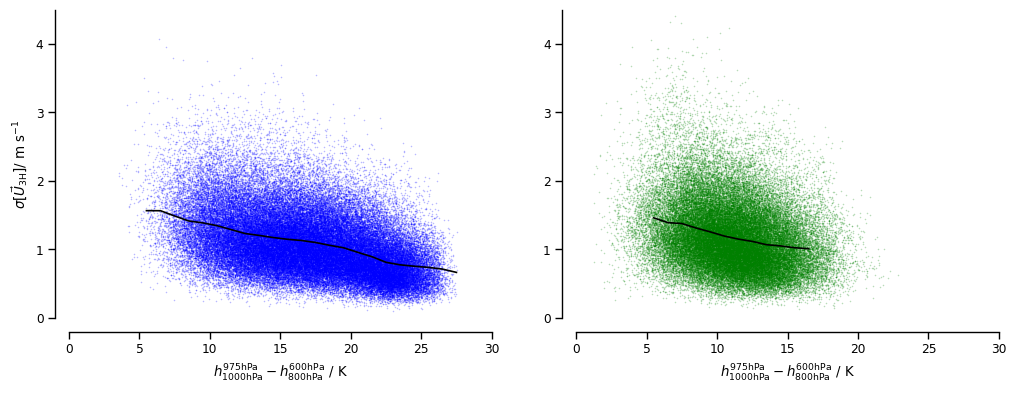

In [24]:
sns.set_context("paper")
fig = plt.figure(figsize=(12,4), facecolor="white")
ax = fig.add_subplot(121)
plt.scatter(((mse_icon-mse_mid_icon)/cp).where(wpacific(ds_icon) & ocean(ds_icon)  & (pr_icon*24*3600>1) ),
            uas_std_icon.where(wpacific(ds_icon) & ocean(ds_icon)),s=0.01,c='b')
bin_dmse_wpacific_icon.plot(color = 'k')
ax.set_ylim([0,4.5])
ax.set_xlim([0,30])
ax.set_yticks(np.arange(0,5,1))
sns.despine(offset=10)
ax.set_xlabel(r'$h_\mathrm{1000 hPa}^\mathrm{975 hPa} - h_\mathrm{800 hPa}^\mathrm{600 hPa}$ / K')
ax.set_ylabel(r"$\sigma$[$\vec{U}_\mathrm{3H}$]/ m s$^{-1}$")

ax = fig.add_subplot(122)
plt.scatter(((mse_nicam-mse_mid_nicam)/cp).where(wpacific(ds_nicam) & ocean(ds_icon) & (p_nicam*24*3600>1)),
          uas_std_nicam.where(wpacific(ds_nicam) & ocean(ds_icon)),s=0.01,c='g')
bin_dmse_wpacific_nicam.plot(color='k')
ax.set_ylim([0,4.5])
ax.set_xlim([0,30])
sns.despine(offset=10)
ax.set_yticks(np.arange(0,5,1))
ax.set_title(None)
ax.set_xlabel(r'$h_\mathrm{1000 hPa}^\mathrm{975 hPa} - h_\mathrm{800 hPa}^\mathrm{600 hPa}$ / K')

Text(0.5, 1.0, 'NICAM')

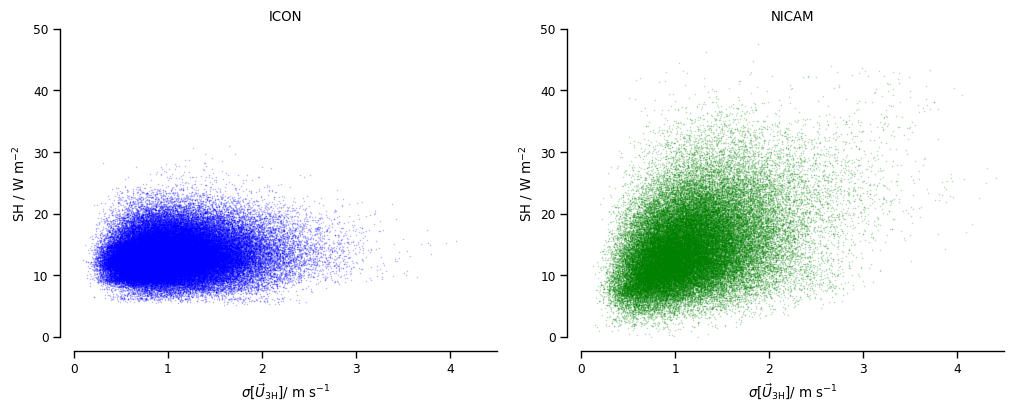

In [28]:
sns.set_context("paper")
fig = plt.figure(figsize=(12,4), facecolor="white")
ax = fig.add_subplot(121)
plt.scatter(uas_std_icon.where(wpacific(ds_icon) & ocean(ds_icon)),
            hfss_icon.where(wpacific(ds_icon) & ocean(ds_icon)  & (pr_icon*24*3600>1) )*-1,
            s=0.01,c='b')

ax.set_xlim([0,4.5])
ax.set_ylim([0,50])
ax.set_xticks(np.arange(0,5,1))
sns.despine(offset=10)
ax.set_ylabel(r'SH / W m$^{-2}$')
ax.set_xlabel(r"$\sigma$[$\vec{U}_\mathrm{3H}$]/ m s$^{-1}$")
ax.set_title('ICON')

ax = fig.add_subplot(122)
plt.scatter(uas_std_nicam.where(wpacific(ds_icon) & ocean(ds_icon)),
            hfss_nicam.where(wpacific(ds_icon) & ocean(ds_icon)  & (p_nicam*24*3600>1) )*-1,
            s=0.01,c='g')
ax.set_xlim([0,4.5])
ax.set_ylim([0,50])
ax.set_xticks(np.arange(0,5,1))
sns.despine(offset=10)
ax.set_ylabel(r'SH / W m$^{-2}$')
ax.set_xlabel(r"$\sigma$[$\vec{U}_\mathrm{3H}$]/ m s$^{-1}$")
ax.set_title(None)
ax.set_title('NICAM')